# DNV-ST-F101 pipeline screening with NeqSim

This example exercises the typed NeqSim screening kernel for a 20-inch submarine export line. It keeps pressure containment, collapse, propagation buckling, local-buckling load interaction, fatigue, ovality, fabrication route, safety class, de-rating, test pressure, and installation strain visible as separate checks.

> **Engineering boundary:** this notebook is an option-screening example, not DNV certification or design approval. Verify every factor and method against the licensed project edition, amendments, design basis, installation analysis, fabrication records, and independent engineering review.

## Calculation basis

The example uses $D=508$ mm, $t_{nom}=28$ mm, 3 mm corrosion allowance, 12.5% negative tolerance, 1.5% ovality, X65-like strength values, medium safety class, and a 300 m-water-depth external-pressure basis. The characteristic screening thickness is

$$t_{char}=t_{nom}(1-f_{tol})-t_{corr}.$$

All pressure values passed to Java are MPa; loads are kN and kN·m; strains are fractions.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

get_ipython().run_line_magic("matplotlib", "inline")


def find_project_root():
    candidates = []
    configured = os.environ.get("NEQSIM_PROJECT_ROOT")
    if configured:
        candidates.append(Path(configured).resolve())
    current = Path.cwd().resolve()
    candidates.extend([current] + list(current.parents))
    for candidate in candidates:
        if (candidate / "pom.xml").exists():
            if (candidate / "devtools" / "neqsim_dev_setup.py").exists():
                return candidate
    return None


classpath_override = os.environ.get("NEQSIM_DNV_CLASSPATH")
project_root = find_project_root()

if classpath_override:
    import jpype

    if not jpype.isJVMStarted():
        jpype.startJVM(classpath=[classpath_override])
    JClass = jpype.JClass
    execution_mode = "compiled-classpath override"
elif project_root is not None:
    sys.path.insert(0, str(project_root / "devtools"))
    from neqsim_dev_setup import neqsim_classes, neqsim_init

    ns = neqsim_init(project_root=project_root, recompile=False, verbose=False)
    ns = neqsim_classes(ns)
    JClass = ns.JClass
    execution_mode = "NeqSim devtools"
else:
    import jpype
    from neqsim import jneqsim

    JClass = jpype.JClass
    execution_mode = "installed NeqSim package"

print(f"Execution mode: {execution_mode}")

In [2]:
Input = JClass(
    "neqsim.process.mechanicaldesign.pipeline.DnvStF101PipelineDesignInput"
)
SafetyClass = JClass(
    "neqsim.process.mechanicaldesign.pipeline."
    "DnvStF101PipelineDesignInput$SafetyClass"
)
FabricationRoute = JClass(
    "neqsim.process.mechanicaldesign.pipeline."
    "DnvStF101PipelineDesignInput$FabricationRoute"
)
Kernel = JClass(
    "neqsim.process.engineering.calculation.DnvStF101PipelineDesignKernel"
)
Context = JClass(
    "neqsim.process.engineering.calculation.EngineeringCalculationContext"
)


def calculate_case(wall_mm=28.0, ovality_pct=1.5, safety_class="MEDIUM"):
    builder = Input.builder()
    builder.safetyClass(SafetyClass.valueOf(safety_class))
    builder.fabricationRoute(FabricationRoute.SEAMLESS)
    builder.geometry(0.508, wall_mm / 1000.0, 0.003)
    builder.fabrication(0.125, ovality_pct / 100.0, 0.030, 1.0)
    builder.material(450.0, 535.0, 207000.0, 0.30)
    builder.resistanceFactors(0.95, 1.0, 0.96, 1.15)
    builder.pressures(15.0, 16.5, 3.0, 0.2, 18.5, 3.0)
    builder.designLoads(1000.0, 1000.0, 250.0)
    builder.installationStrains(0.002, 0.005, 0.003, 0.025)
    builder.fatigueCurve(12.0, 3.0, 1.0, 3.0)
    builder.addFatigueBin(60.0, 100000.0)
    builder.addFatigueBin(80.0, 50000.0)
    context = (
        Context.builder()
        .designCaseId("20-inch export line")
        .addStandardReference("DNV-ST-F101 2021 licensed project copy")
        .build()
    )
    return Kernel().calculate(builder.build(), context)


def checks_frame(result):
    rows = []
    for check in result.getValue().getChecks():
        rows.append(
            {
                "limit_state": str(check.getLimitState()),
                "status": str(check.getStatus()),
                "demand": float(check.getDemand()),
                "resistance": float(check.getResistance()),
                "utilization": float(check.getUtilization()),
                "unit": str(check.getUnit()),
            }
        )
    return pd.DataFrame(rows)

In [3]:
baseline_result = calculate_case()
assert str(baseline_result.getStatus()) == "CALCULATED_REVIEW_REQUIRED"
assert baseline_result.getReadiness().isReady()

baseline = checks_frame(baseline_result)
baseline.style.format(
    {"demand": "{:.3f}", "resistance": "{:.3f}", "utilization": "{:.3f}"}
)

,limit_state,status,demand,resistance,utilization,unit
0,OPERATING_PRESSURE_CONTAINMENT,PASS,12.000,16.669,0.720,MPa
1,INCIDENTAL_PRESSURE_CONTAINMENT,PASS,13.500,16.669,0.810,MPa
2,SYSTEM_TEST_PRESSURE_CONTAINMENT,PASS,15.500,16.669,0.930,MPa
3,EXTERNAL_PRESSURE_COLLAPSE,PASS,2.800,17.055,0.164,MPa
4,PROPAGATION_BUCKLING,PASS,2.800,4.213,0.665,MPa
5,LOCAL_BUCKLING_LOAD_INTERACTION,FAIL,1.024,1.000,1.024,ratio
6,FATIGUE,PASS,0.142,1.000,0.142,damage ratio
7,OVALITY,PASS,0.015,0.030,0.500,fraction
8,INSTALLATION_STRAIN,PASS,0.010,0.025,0.400,strain fraction


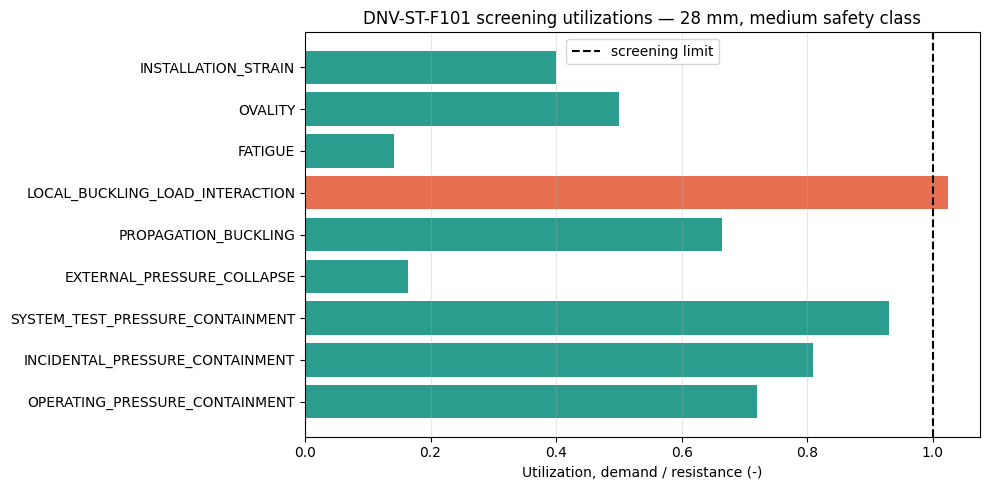

In [4]:
colors = np.where(baseline["utilization"] <= 1.0, "#2a9d8f", "#e76f51")
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(baseline["limit_state"], baseline["utilization"], color=colors)
ax.axvline(1.0, color="black", linestyle="--", label="screening limit")
ax.set_xlabel("Utilization, demand / resistance (-)")
ax.set_title("DNV-ST-F101 screening utilizations — 28 mm, medium safety class")
ax.grid(axis="x", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Figure 1 discussion

**Observation:** local-buckling load interaction governs at 1.024, slightly above the screening limit. System-test containment is next at 0.930; collapse is only 0.164. **Mechanism:** axial/bending/torsion and incidental pressure combine in the local interaction envelope even though each pressure-only check passes. **Engineering implication:** pressure containment alone would miss the governing finding. **Recommendation:** refine the project load cases and clause-level local-buckling assessment; do not accept the 28 mm option from this screen.

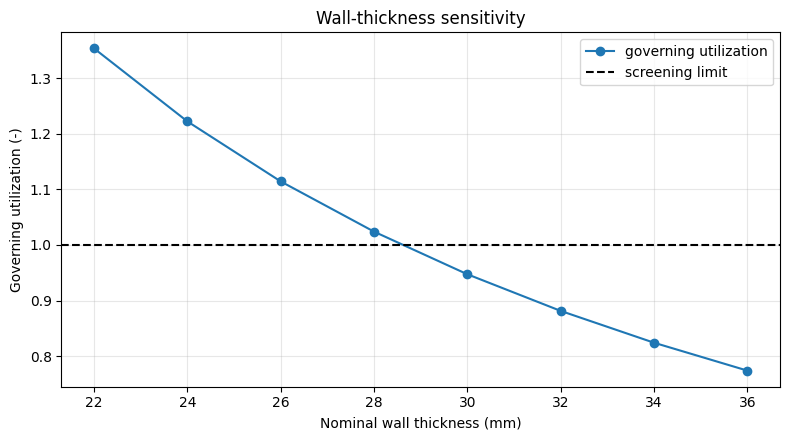

,wall_mm,governing_limit_state,governing_utilization
0,22.0,LOCAL_BUCKLING_LOAD_INTERACTION,1.353624
1,24.0,LOCAL_BUCKLING_LOAD_INTERACTION,1.222327
2,26.0,LOCAL_BUCKLING_LOAD_INTERACTION,1.114352
3,28.0,LOCAL_BUCKLING_LOAD_INTERACTION,1.024006
4,30.0,LOCAL_BUCKLING_LOAD_INTERACTION,0.947309
5,32.0,LOCAL_BUCKLING_LOAD_INTERACTION,0.881395
6,34.0,LOCAL_BUCKLING_LOAD_INTERACTION,0.824147
7,36.0,LOCAL_BUCKLING_LOAD_INTERACTION,0.773972


In [5]:
wall_values = np.arange(22.0, 36.1, 2.0)
governing_values = []
governing_names = []
for wall_mm in wall_values:
    assessment = calculate_case(wall_mm=wall_mm).getValue()
    governing = assessment.getGoverningCheck()
    governing_values.append(float(governing.getUtilization()))
    governing_names.append(str(governing.getLimitState()))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(wall_values, governing_values, marker="o", label="governing utilization")
ax.axhline(1.0, color="black", linestyle="--", label="screening limit")
ax.set_xlabel("Nominal wall thickness (mm)")
ax.set_ylabel("Governing utilization (-)")
ax.set_title("Wall-thickness sensitivity")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame(
    {
        "wall_mm": wall_values,
        "governing_limit_state": governing_names,
        "governing_utilization": governing_values,
    }
)

### Figure 2 discussion

**Observation:** governing utilization falls from 1.354 at 22 mm to 0.774 at 36 mm; the screen first drops below 1.0 at 30 mm (0.947). **Mechanism:** added wall increases burst, section, collapse, and propagation resistance together. **Engineering implication:** 30 mm is the first passing point in this discrete sweep, not a selected nominal wall. **Recommendation:** investigate a continuous thickness range around 28–30 mm, then apply availability, mill tolerance, corrosion, installation, fatigue, and approved clause checks before selection.

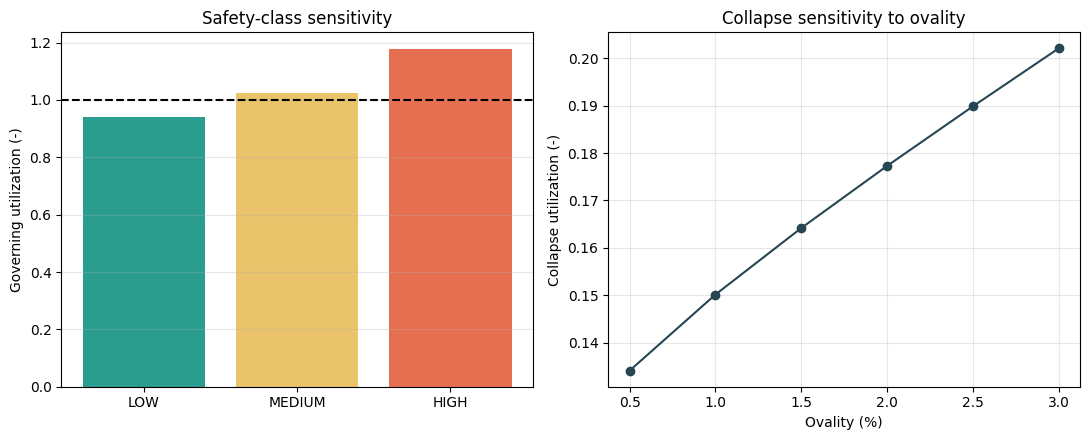

In [6]:
safety_classes = ["LOW", "MEDIUM", "HIGH"]
safety_governing = [
    float(calculate_case(safety_class=name).getValue().getGoverningCheck().getUtilization())
    for name in safety_classes
]

ovality_values = np.arange(0.5, 3.01, 0.5)
collapse_values = []
for ovality_pct in ovality_values:
    frame = checks_frame(calculate_case(ovality_pct=ovality_pct))
    collapse = frame.loc[
        frame["limit_state"] == "EXTERNAL_PRESSURE_COLLAPSE", "utilization"
    ].iloc[0]
    collapse_values.append(collapse)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(safety_classes, safety_governing, color=["#2a9d8f", "#e9c46a", "#e76f51"])
axes[0].axhline(1.0, color="black", linestyle="--")
axes[0].set_ylabel("Governing utilization (-)")
axes[0].set_title("Safety-class sensitivity")
axes[0].grid(axis="y", alpha=0.3)
axes[1].plot(ovality_values, collapse_values, marker="o", color="#264653")
axes[1].set_xlabel("Ovality (%)")
axes[1].set_ylabel("Collapse utilization (-)")
axes[1].set_title("Collapse sensitivity to ovality")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Figure 3 discussion

**Observation:** the governing utilization rises from 0.941 in low safety class to 1.024 in medium and 1.177 in high. Collapse utilization rises from 0.134 at 0.5% ovality to 0.202 at 3.0%. **Mechanism:** the safety-class factor reduces all relevant resistances, while ovality directly reduces the elastic-plastic collapse resistance. **Engineering implication:** neither consequence class nor fabrication geometry can be treated as a cost-only attribute. **Recommendation:** obtain the project safety classification and mill/installation ovality envelope before freezing wall thickness or buckle-control philosophy.

## Takeaways

- The API returns `CALCULATED_REVIEW_REQUIRED`, even when every implemented utilization is below 1.0.
- Operating, incidental, and system-test pressure remain separate.
- Collapse uses ovality and fabrication factor; propagation buckling remains an independent check.
- Fatigue and installation strain require explicit spectra/limits rather than hidden defaults.
- The local-buckling interaction is deliberately labelled as a screening envelope and must be replaced or verified with the project-approved method for design approval.